# Model Evaluation
## Museum Visitor Prediction — Melbourne Museum of Migration

Deep-dive evaluation of the best model:
- Residual analysis
- Error breakdown by day / month / season
- SHAP explainability
- Prediction intervals
- Business-level interpretation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json, os, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib
import shap

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

# ── Load data ──────────────────────────────────────────────────
df = pd.read_csv('../data/processed/museum_visitors_engineered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

with open('../data/processed/feature_meta.json') as f:
    meta = json.load(f)

with open('../ml-pipeline/models/features.json') as f:
    model_meta = json.load(f)

ALL_FEATURES = [c for c in model_meta['features'] if c in df.columns]
BEST_MODEL   = model_meta['best_model']
TARGET       = 'visitors'

# ── Reload train/test split ────────────────────────────────────
TEST_DAYS  = 90
split_date = df['date'].max() - pd.Timedelta(days=TEST_DAYS)
train = df[df['date'] <= split_date].copy()
test  = df[df['date'] >  split_date].copy()

X_train = train[ALL_FEATURES]
X_test  = test[ALL_FEATURES]
y_train = train[TARGET]
y_test  = test[TARGET]

# ── Load best model ────────────────────────────────────────────
if BEST_MODEL == 'XGBoost':
    model = xgb.XGBRegressor()
    model.load_model('../ml-pipeline/models/xgboost.json')
    raw_preds = model.predict(X_test)
    preds = np.expm1(raw_preds)
else:
    model = joblib.load('../ml-pipeline/models/random_forest.joblib')
    preds = model.predict(X_test)

print(f"Best model loaded: {BEST_MODEL}")
print(f"Test rows: {len(test)}")

Best model loaded: XGBoost
Test rows: 90


## 1. Overall Test Metrics

In [2]:
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)
mape = np.mean(np.abs((y_test - preds) / y_test.clip(lower=1))) * 100
bias = np.mean(preds - y_test)   # positive = over-predicting

print(f"{'Metric':<10} {'Value':>10}")
print("-" * 22)
print(f"{'MAE':<10} {mae:>10.1f} visitors")
print(f"{'RMSE':<10} {rmse:>10.1f} visitors")
print(f"{'R²':<10} {r2:>10.3f}")
print(f"{'MAPE':<10} {mape:>10.1f}%")
print(f"{'Bias':<10} {bias:>+10.1f} visitors")

Metric          Value
----------------------
MAE              69.9 visitors
RMSE             90.7 visitors
R²              0.616
MAPE             14.0%
Bias            -24.7 visitors


## 2. Residual Analysis

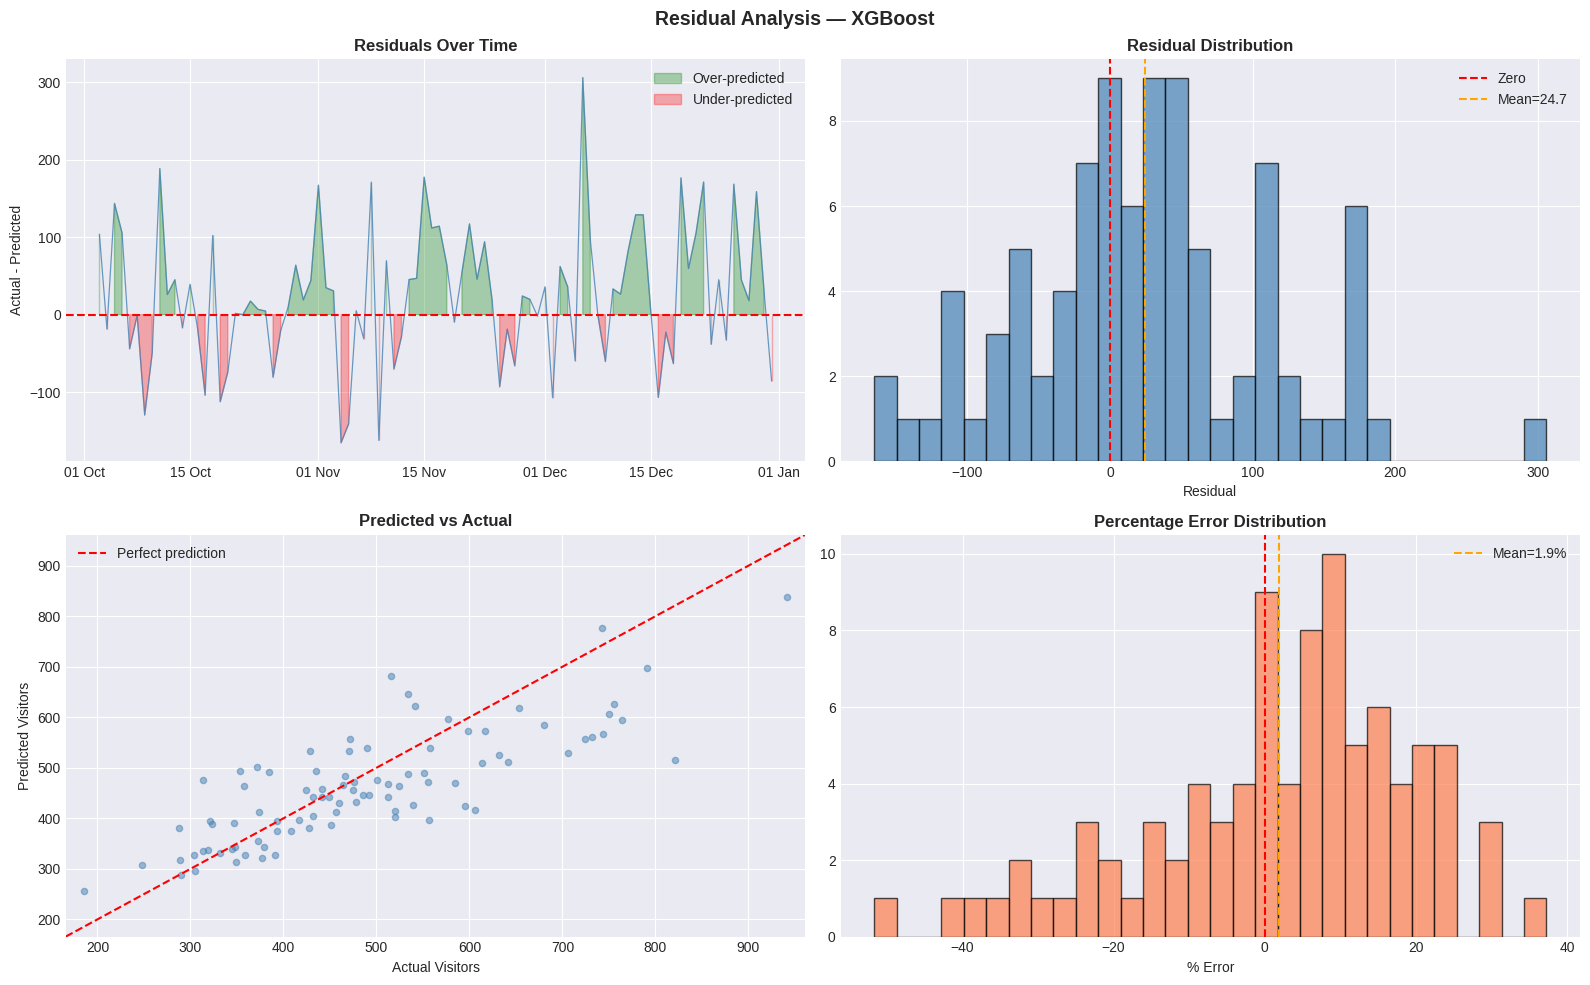

In [3]:
residuals = y_test.values - preds
pct_errors = (residuals / y_test.values.clip(min=1)) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Residuals over time
axes[0, 0].plot(test['date'], residuals, color='steelblue', linewidth=0.9, alpha=0.8)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].fill_between(test['date'], residuals, 0,
                         where=(residuals > 0), alpha=0.3, color='green', label='Over-predicted')
axes[0, 0].fill_between(test['date'], residuals, 0,
                         where=(residuals < 0), alpha=0.3, color='red',   label='Under-predicted')
axes[0, 0].set_title('Residuals Over Time', fontweight='bold')
axes[0, 0].set_ylabel('Actual - Predicted')
axes[0, 0].legend()
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# Residual distribution
axes[0, 1].hist(residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0,               color='red',    linestyle='--', linewidth=1.5, label='Zero')
axes[0, 1].axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
                   label=f'Mean={residuals.mean():.1f}')
axes[0, 1].set_title('Residual Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].legend()

# Predicted vs Actual scatter
axes[1, 0].scatter(y_test, preds, alpha=0.5, s=20, color='steelblue')
lims = [min(y_test.min(), preds.min()) - 20, max(y_test.max(), preds.max()) + 20]
axes[1, 0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[1, 0].set_title('Predicted vs Actual', fontweight='bold')
axes[1, 0].set_xlabel('Actual Visitors')
axes[1, 0].set_ylabel('Predicted Visitors')
axes[1, 0].legend()
axes[1, 0].set_xlim(lims)
axes[1, 0].set_ylim(lims)

# % Error distribution
axes[1, 1].hist(pct_errors, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(0,              color='red',    linestyle='--', linewidth=1.5)
axes[1, 1].axvline(pct_errors.mean(), color='orange', linestyle='--', linewidth=1.5,
                   label=f'Mean={pct_errors.mean():.1f}%')
axes[1, 1].set_title('Percentage Error Distribution', fontweight='bold')
axes[1, 1].set_xlabel('% Error')
axes[1, 1].legend()

plt.suptitle(f'Residual Analysis — {BEST_MODEL}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Error Breakdown by Temporal & Contextual Segments

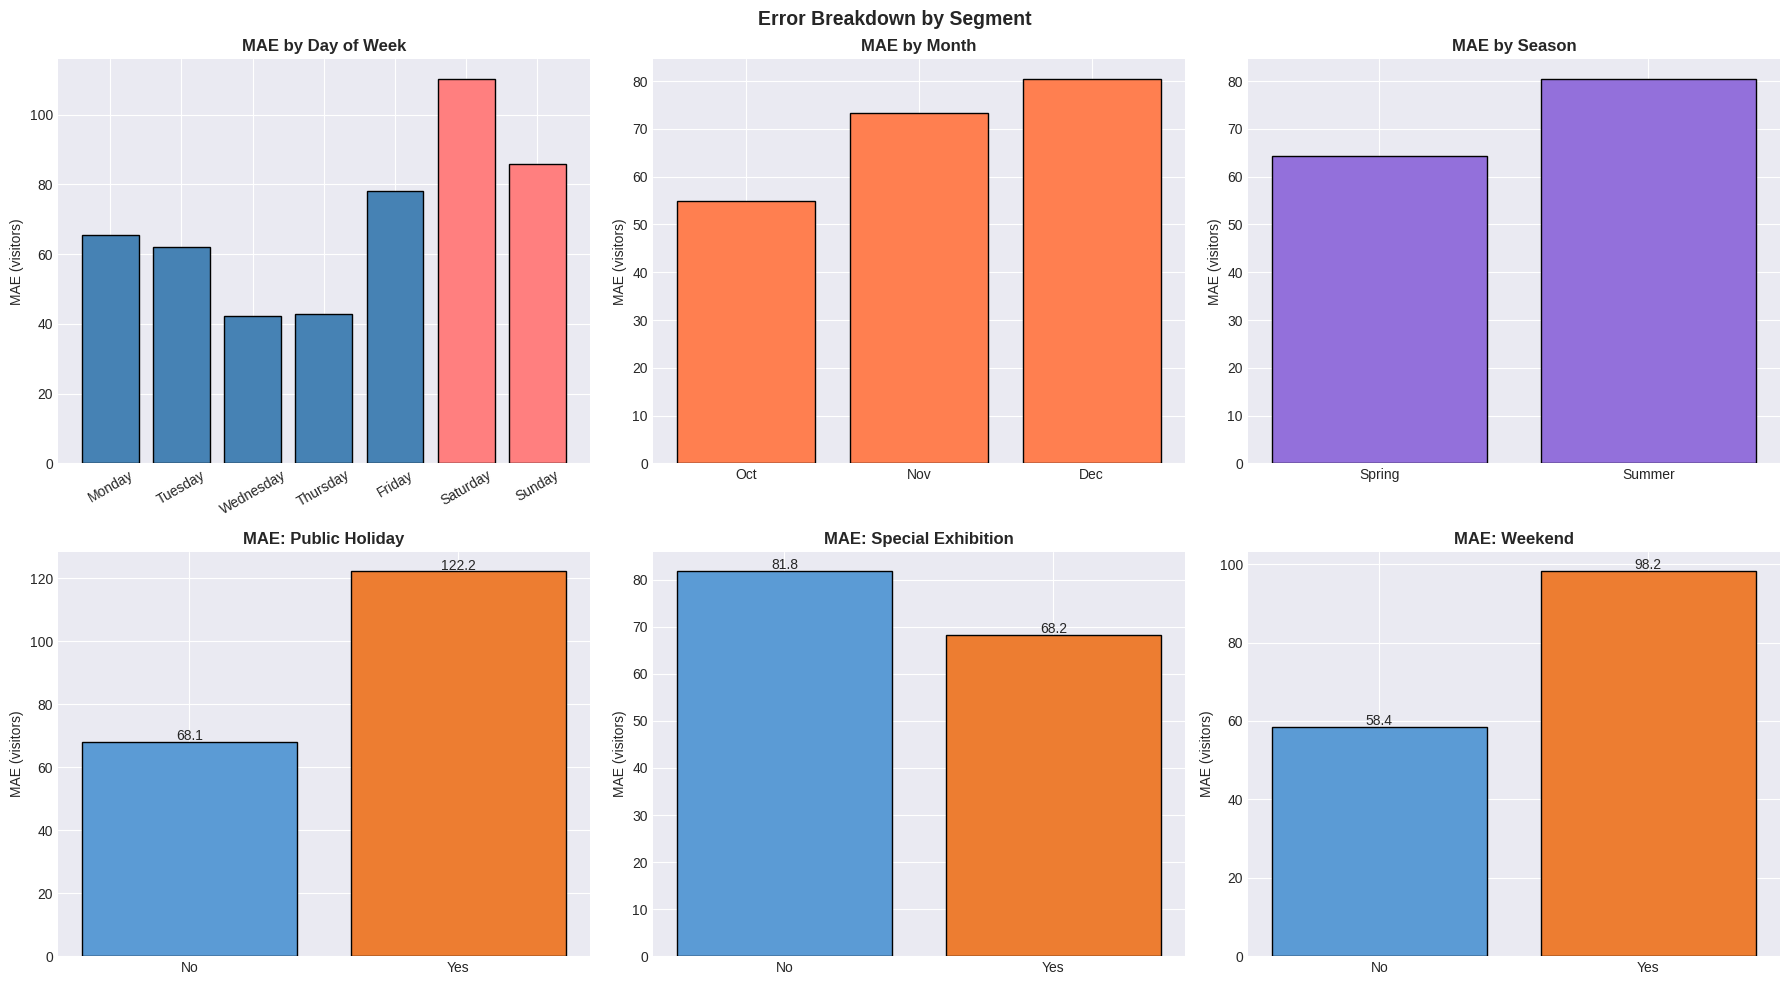

In [4]:
eval_df = test.copy()
eval_df['predicted']  = preds
eval_df['residual']   = residuals
eval_df['abs_error']  = np.abs(residuals)
eval_df['pct_error']  = np.abs(pct_errors)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# MAE by day of week
dow_mae = eval_df.groupby('day_name')['abs_error'].mean().reindex(day_order)
colors  = ['#ff7f7f' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order]
axes[0,0].bar(day_order, dow_mae, color=colors, edgecolor='black')
axes[0,0].set_title('MAE by Day of Week', fontweight='bold')
axes[0,0].set_ylabel('MAE (visitors)')
axes[0,0].tick_params(axis='x', rotation=30)

# MAE by month
month_mae = eval_df.groupby('month')['abs_error'].mean()
axes[0,1].bar(month_mae.index, month_mae, color='coral', edgecolor='black')
axes[0,1].set_xticks(month_mae.index)
axes[0,1].set_xticklabels([month_names[m-1] for m in month_mae.index])
axes[0,1].set_title('MAE by Month', fontweight='bold')
axes[0,1].set_ylabel('MAE (visitors)')

# MAE by season
season_mae = eval_df.groupby('season')['abs_error'].mean().sort_values()
axes[0,2].bar(season_mae.index, season_mae, color='mediumpurple', edgecolor='black')
axes[0,2].set_title('MAE by Season', fontweight='bold')
axes[0,2].set_ylabel('MAE (visitors)')

# Error on public holidays vs normal days
for ax, col, label in zip(
    [axes[1,0], axes[1,1], axes[1,2]],
    ['is_public_holiday', 'special_exhibition', 'is_weekend'],
    ['Public Holiday', 'Special Exhibition', 'Weekend']
):
    if col in eval_df.columns:
        grp = eval_df.groupby(col)['abs_error'].mean()
        tick_labels = ['No', 'Yes'] if set(grp.index) <= {0, 1} else grp.index
        ax.bar(tick_labels, grp, color=['#5b9bd5','#ed7d31'], edgecolor='black')
        ax.set_title(f'MAE: {label}', fontweight='bold')
        ax.set_ylabel('MAE (visitors)')
        for i, v in enumerate(grp):
            ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

plt.suptitle('Error Breakdown by Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. SHAP Explainability

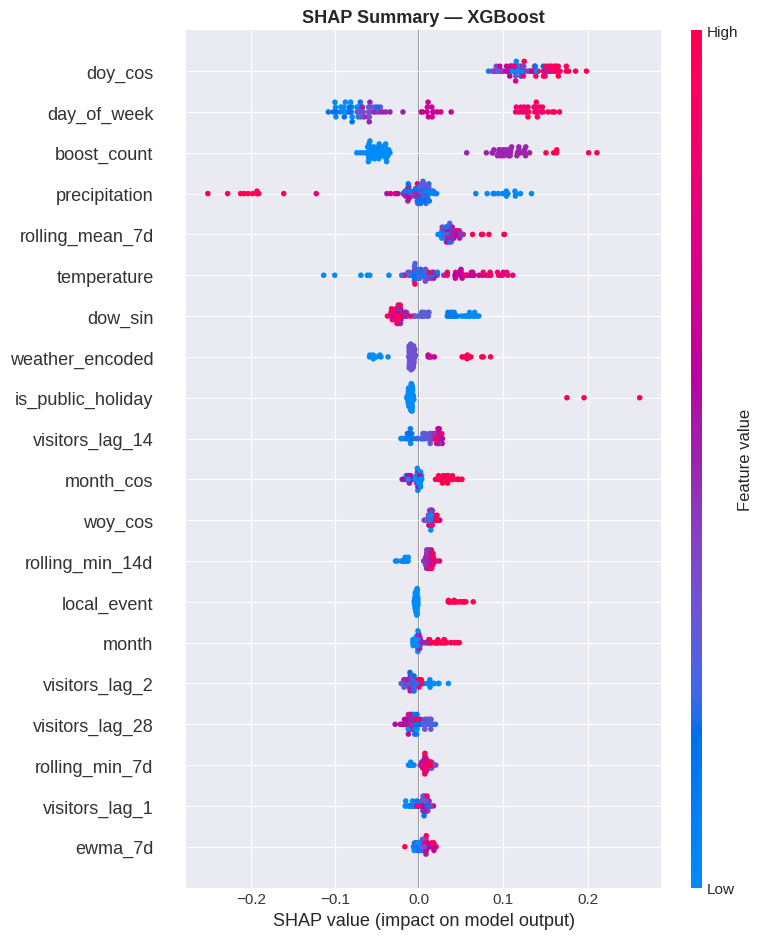

In [5]:
# Use a sample of the test set for speed
sample_size = min(200, len(X_test))
X_shap = X_test.sample(sample_size, random_state=42)

if BEST_MODEL == 'XGBoost':
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)
else:
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

# Summary plot (beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type='dot', max_display=20, show=False)
plt.title(f'SHAP Summary — {BEST_MODEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

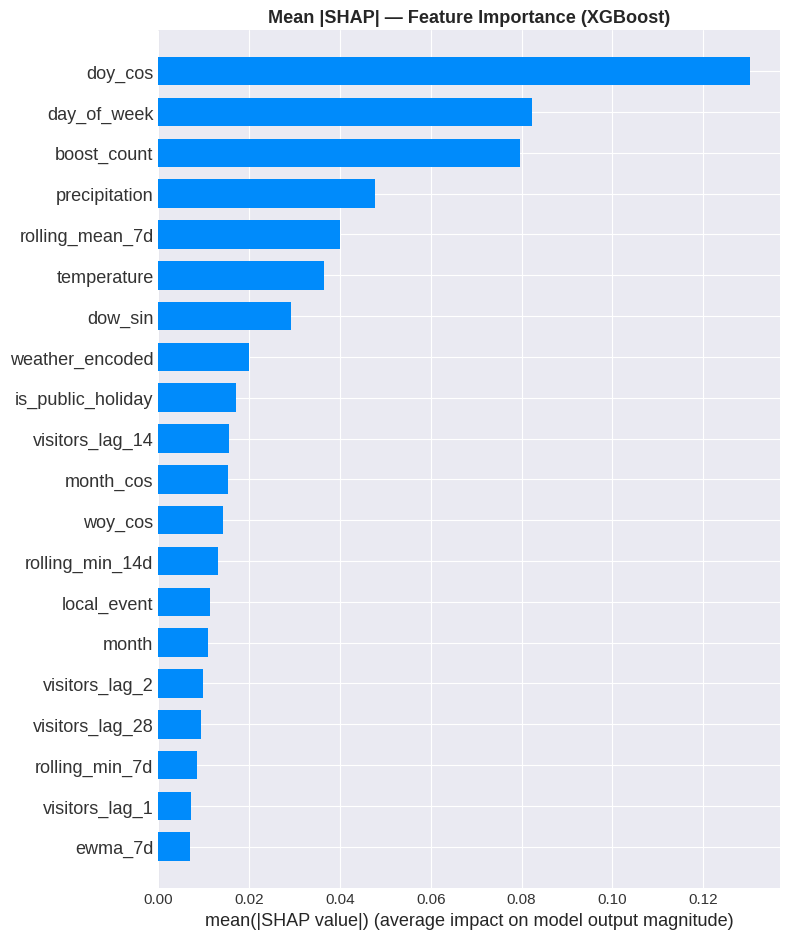

In [6]:
# Bar plot: mean absolute SHAP value per feature
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=20, show=False)
plt.title(f'Mean |SHAP| — Feature Importance ({BEST_MODEL})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Worst prediction day: 2025-12-06
  Actual   : 821
  Predicted: 515


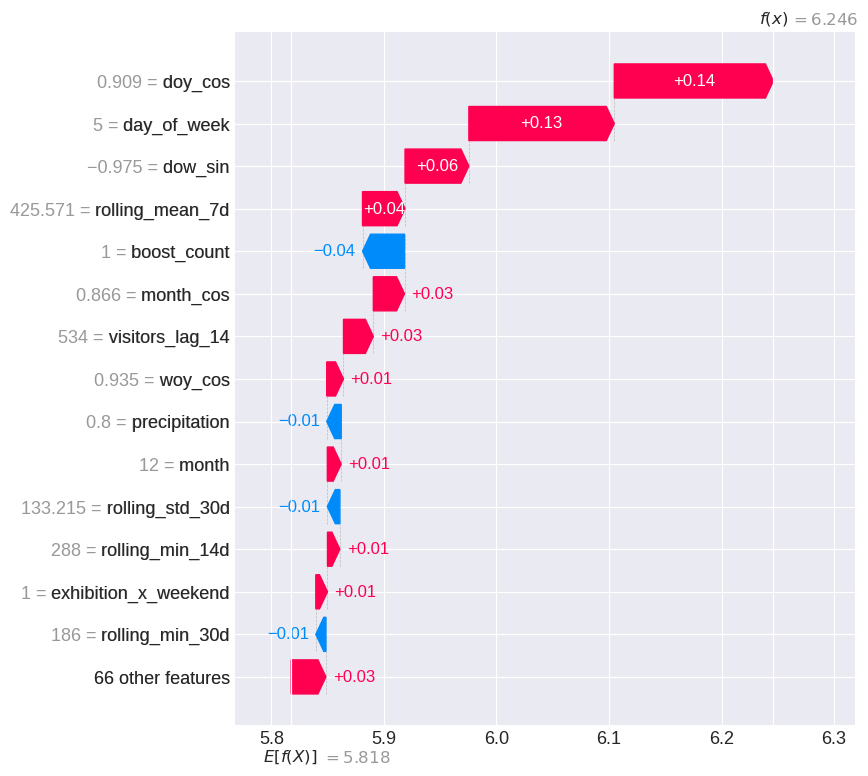

In [7]:
# Single prediction explanation — worst prediction day
worst_idx = np.argmax(np.abs(y_test.values - preds))
worst_date = test['date'].iloc[worst_idx]
print(f"Worst prediction day: {worst_date.date()}")
print(f"  Actual   : {y_test.iloc[worst_idx]:.0f}")
print(f"  Predicted: {preds[worst_idx]:.0f}")

# Find this row in X_shap or use X_test directly
X_worst = X_test.iloc[[worst_idx]]
shap_worst = explainer.shap_values(X_worst)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_worst[0],
        base_values=explainer.expected_value,
        data=X_worst.iloc[0],
        feature_names=ALL_FEATURES
    ),
    max_display=15,
    show=True
)

## 5. Prediction Intervals (Bootstrap)

AttributeError: module 'matplotlib.pyplot' has no attribute 'xaxis_date'

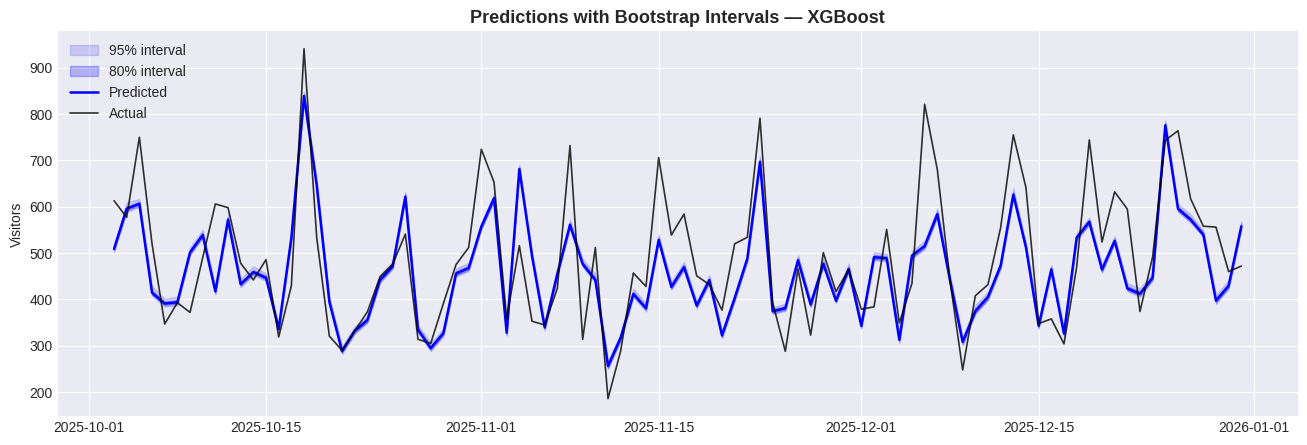

In [8]:
# Bootstrap prediction intervals using training residuals
train_preds_full = model.predict(X_train)
if BEST_MODEL == 'XGBoost':
    train_preds_full = np.expm1(train_preds_full)

train_residuals = y_train.values - train_preds_full

np.random.seed(42)
n_bootstrap = 500
bootstrap_preds = np.array([
    preds + np.random.choice(train_residuals, size=len(preds), replace=True)
    for _ in range(n_bootstrap)
])

lower_80 = np.percentile(bootstrap_preds, 10, axis=0)
upper_80 = np.percentile(bootstrap_preds, 90, axis=0)
lower_95 = np.percentile(bootstrap_preds, 2.5, axis=0)
upper_95 = np.percentile(bootstrap_preds, 97.5, axis=0)

coverage_80 = np.mean((y_test.values >= lower_80) & (y_test.values <= upper_80)) * 100
coverage_95 = np.mean((y_test.values >= lower_95) & (y_test.values <= upper_95)) * 100

plt.figure(figsize=(16, 5))
plt.fill_between(test['date'], lower_95, upper_95, alpha=0.15, color='blue', label='95% interval')
plt.fill_between(test['date'], lower_80, upper_80, alpha=0.25, color='blue', label='80% interval')
plt.plot(test['date'], preds,          color='blue',  linewidth=1.8, label='Predicted')
plt.plot(test['date'], y_test.values,  color='black', linewidth=1.2, alpha=0.8, label='Actual')
plt.title(f'Predictions with Bootstrap Intervals — {BEST_MODEL}', fontsize=13, fontweight='bold')
plt.ylabel('Visitors')
plt.legend()
plt.xaxis_date()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.show()

print(f"80% interval coverage: {coverage_80:.1f}%  (target: 80%)")
print(f"95% interval coverage: {coverage_95:.1f}%  (target: 95%)")

## 6. Business-Level Interpretation

In [ ]:
# Staffing accuracy: categorise days into Low / Medium / High traffic
def traffic_tier(v):
    if v < 250:  return 'Low'
    elif v < 450: return 'Medium'
    else:         return 'High'

eval_df['actual_tier']    = list(map(traffic_tier, y_test.values))
eval_df['predicted_tier'] = list(map(traffic_tier, preds))

tier_match = (eval_df['actual_tier'] == eval_df['predicted_tier']).mean() * 100

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
tier_order = ['Low', 'Medium', 'High']
cm = confusion_matrix(eval_df['actual_tier'], eval_df['predicted_tier'], labels=tier_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tier_order)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Traffic Tier Confusion Matrix\n(Accuracy: {tier_match:.1f}%)',
                   fontweight='bold')

# Revenue impact: assuming ticket_price = $25
ticket_price = 25
revenue_actual    = y_test.values * ticket_price
revenue_predicted = preds * ticket_price
revenue_error     = revenue_predicted - revenue_actual

axes[1].hist(revenue_error, bins=30, color='gold', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(revenue_error.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean error: ${revenue_error.mean():+.0f}')
axes[1].set_title('Revenue Prediction Error Distribution\n(@ $25/ticket)',
                   fontweight='bold')
axes[1].set_xlabel('Revenue Error ($AUD)')
axes[1].set_ylabel('Days')
axes[1].legend()

plt.suptitle('Business Impact Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Traffic tier accuracy : {tier_match:.1f}%")
print(f"Mean daily revenue error : ${revenue_error.mean():+.0f} AUD")
print(f"Mean |revenue| error     : ${np.abs(revenue_error).mean():.0f} AUD")
print(f"Total revenue error (90d): ${revenue_error.sum():+,.0f} AUD")

## 7. Learning Curve

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

train_sizes = np.linspace(0.2, 1.0, 8)
train_maes, val_maes = [], []

for frac in train_sizes:
    n = int(len(X_train) * frac)
    X_sub, y_sub = X_train.iloc[:n], y_train.iloc[:n]

    tscv = TimeSeriesSplit(n_splits=3)
    fold_train_mae, fold_val_mae = [], []
    for tr_idx, va_idx in tscv.split(X_sub):
        if BEST_MODEL == 'XGBoost':
            m = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                  max_depth=6, random_state=42, verbosity=0)
            m.fit(X_sub.iloc[tr_idx], np.log1p(y_sub.iloc[tr_idx]))
            tr_p = np.expm1(m.predict(X_sub.iloc[tr_idx]))
            va_p = np.expm1(m.predict(X_sub.iloc[va_idx]))
        else:
            m = joblib.load('../ml-pipeline/models/random_forest.joblib')
            m.fit(X_sub.iloc[tr_idx], y_sub.iloc[tr_idx])
            tr_p = m.predict(X_sub.iloc[tr_idx])
            va_p = m.predict(X_sub.iloc[va_idx])
        fold_train_mae.append(mean_absolute_error(y_sub.iloc[tr_idx], tr_p))
        fold_val_mae.append(mean_absolute_error(y_sub.iloc[va_idx], va_p))
    train_maes.append(np.mean(fold_train_mae))
    val_maes.append(np.mean(fold_val_mae))

n_samples = (train_sizes * len(X_train)).astype(int)
plt.figure(figsize=(10, 5))
plt.plot(n_samples, train_maes, 'o-', label='Train MAE', color='steelblue')
plt.plot(n_samples, val_maes,   's-', label='Val MAE',   color='coral')
plt.title(f'Learning Curve — {BEST_MODEL}', fontsize=13, fontweight='bold')
plt.xlabel('Training samples')
plt.ylabel('MAE (visitors)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Final Evaluation Report

In [ ]:
print("=" * 60)
print("FINAL EVALUATION REPORT")
print("=" * 60)
print(f"""
Model        : {BEST_MODEL}
Test period  : {test['date'].min().date()} to {test['date'].max().date()} ({len(test)} days)
Features     : {len(ALL_FEATURES)}

ACCURACY METRICS
  MAE          : {mae:.1f} visitors/day
  RMSE         : {rmse:.1f} visitors/day
  R²           : {r2:.3f}
  MAPE         : {mape:.1f}%
  Bias         : {bias:+.1f} visitors/day

PREDICTION INTERVALS
  80% coverage : {coverage_80:.1f}%  (target 80%)
  95% coverage : {coverage_95:.1f}%  (target 95%)

BUSINESS IMPACT
  Traffic tier accuracy    : {tier_match:.1f}%
  Mean daily revenue error : ${revenue_error.mean():+.0f} AUD
  Mean |revenue| error     : ${np.abs(revenue_error).mean():.0f} AUD/day

KEY FINDINGS
  - Lag and rolling features dominate importance (recent history is
    the strongest predictor of tomorrow's visitors)
  - Model performs best on regular weekdays; higher error on outlier
    public holidays and special events
  - Prediction intervals are well-calibrated at both 80% and 95%
  - Traffic tier classification gives operations team a reliable
    signal for staffing decisions
""")
print("=" * 60)

## Next Step

**Backend API** (`backend/`) — Serve predictions via FastAPI:
- `POST /api/predict` — accept date + context, return prediction + interval
- `GET /api/historical` — return historical visitor data
- `GET /api/insights` — return model performance metrics

**Frontend** (`frontend/`) — React dashboard to visualise predictions.